# Pairs trading, rebuilt as a research backtest
**Aghna Datta · US banks · reproducible review of commit `4cae5e7`**

This notebook tests whether a simple pairs strategy survives chronological
screening, executable timing and consistent accounting. It includes the original
saved dataset and repository snapshot. Run the cells to see whether any pair qualifies
and what the resulting account earns. Zero eligible pairs means holding cash.

**Start here.** Extract the complete ZIP, open the `pairs_trading_research` folder
in VS Code, select Python 3.12 with `requirements.txt` installed, restart the kernel
and run all cells. The code writes generated tables and charts to `results/`.
No analysis cells have been run in this copy; execution counts and outputs are clear.
The code uses only the accompanying data and does not download live prices.

1. Research question and strategy intuition
2. Data, assumptions and limitations
3. Cointegration screening and chronological evaluation
4. Spread, hedge ratios and signals
5. Execution, sizing, costs and accounting
6. Validation
7. Results and limited robustness checks
8. Original-versus-corrected comparison
9. Conclusions and interview talking points


## 1. Research question and strategy intuition

Banks share drivers such as interest rates, credit conditions and economic growth.
Two related share prices might temporarily depart from a stable long-run relationship.
Buying the relatively cheap side and shorting the relatively expensive side can then
profit if that relationship reasserts itself. Shared business exposure is an economic
motivation, not a guarantee: different loan books, funding models, acquisitions and
stress events can permanently change relative values.

**Correlation and cointegration answer different questions.** Return correlation
describes co-movement over a chosen horizon. Cointegration asks whether a linear
combination of individually non-stationary price levels is stationary. Highly correlated
returns do not ensure a stable price-level residual. Cointegration is also not an
arbitrage certificate: the spread can diverge before converging, coefficients can
change, and costs can exceed convergence gains.

For this deliberately narrow set of ten large US banks and broker-dealers, the question is: **does a relationship selected using only past observations produce
credible subsequent account returns under fixed rules?** This notebook can answer
that question only for the supplied universe, sample and assumptions. It does not
estimate live tradability, future profitability or a pricing model for energy products.
The relevant Junior Pricing Analyst skills are causal use of information, matching
hedge units to monetary exposure, reconciling P&L and stating model limitations.

In [1]:
%matplotlib inline
from pathlib import Path
import hashlib
import importlib.metadata as metadata
import json
import platform
import subprocess
import sys
import zipfile

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from strategy import (check_prices, make_schedule, spread_zscore, size_position,
                      simulate_pair, run_walk_forward, performance_metrics, cost_scenarios)

ROOT = Path.cwd()
assert (ROOT / "strategy.py").is_file(), "Run from the extracted project directory."
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (10, 4), "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 14)

In [2]:
# These values were chosen before running the corrected historical baseline.
TICKERS = ["JPM", "BAC", "WFC", "C", "GS", "MS", "USB", "PNC", "TFC", "BK"]
FORMATION_DAYS = 504
TRADING_DAYS = 126
SLOTS = 2
INITIAL_CAPITAL = 100_000.0
Z_WINDOW = 60
TRADING = dict(entry_z=2.0, exit_z=0.5, stop_z=3.5, max_hold=20,
               gross_target=0.8, max_gross=1.0,
               cost_bps=5.0, borrow_rate=0.01, finance_rate=0.05)
ORIGINAL_COMMIT = "4cae5e7cbce6ad2bd851693fc9e0db6c1387922e"
EXPECTED_DATA_SHA256 = "60592195d877570a292af271879b8437fb6b924ce3bdd4ac8e5b0faeb26c8825"

configuration = dict(tickers=TICKERS, formation_days=FORMATION_DAYS,
    trading_days=TRADING_DAYS, slots=SLOTS, initial_capital_usd=INITIAL_CAPITAL,
    z_window=Z_WINDOW, trading=TRADING, screening="Bonferroni 5% across 45 pairs",
    adf="constant; maxlag=10; AIC; levels p>0.05, differences p<0.05",
    cointegration="Engle-Granger; alphabetical Y,X; constant; maxlag=10; AIC",
    execution="Fixed units ordered at close t; next-close fill t+1",
    cash_rate=0.0, sortino_daily_target=0.0, annualisation_sessions=252,
    carry_day_count="actual calendar days / 365", original_commit=ORIGINAL_COMMIT)
(RESULTS / "configuration.json").write_text(json.dumps(configuration, indent=2))
display(pd.Series({**TRADING, "formation_days": FORMATION_DAYS,
                   "trading_days": TRADING_DAYS, "z_window": Z_WINDOW}, name="Baseline"))

entry_z             2.00
exit_z              0.50
stop_z              3.50
max_hold           20.00
gross_target        0.80
max_gross           1.00
cost_bps            5.00
borrow_rate         0.01
finance_rate        0.05
formation_days    504.00
trading_days      126.00
z_window           60.00
Name: Baseline, dtype: float64

## 2. Data, assumptions and limitations

The preserved CSV contains **1,905 rows, 2 January 2018–31 July 2025**, for the original
ten US bank symbols. Its bytes are checked against both a SHA-256 fingerprint and
the unmodified commit archive. The repository's current HEAD was still the reviewed
commit when inspected on 26 September 2026. The original download timestamp is unknown.

The original `utils.py:fetch_data` calls Yahoo Finance through `yfinance` with
`auto_adjust=True`, then drops entirely missing rows and forward-fills. We therefore
treat the saved closes as a **split/dividend-adjusted research approximation**, based
on the source code's stated provenance. Neither raw prices nor corporate-action
records were saved, so the individual adjustments cannot be independently reconciled.
The [yfinance documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html)
describes the automatic OHLC adjustment option; the local original source records its use.

We make no further fills. Missing, non-finite, non-positive or duplicate-dated input
causes a visible failure. Unchanged consecutive prices are flagged but do not prove
forward-filling: genuine unchanged closes also occur. The maximum date gap is checked,
but there is no independent exchange-calendar completeness audit. Previously filled
observations cannot be recovered from this CSV.

**Corporate and universe history.** TFC was not the name of the combined bank in 2018.
BB&T survived its merger with SunTrust and changed its name/ticker in December 2019
([SEC filing](https://www.sec.gov/Archives/edgar/data/750556/000119312519308629/d808889d8k.htm)).
The pre-merger TFC-labelled rows are interpreted as vendor-linked predecessor history;
the CSV alone cannot independently establish the mapping. Combining histories can
hide an economic structural break. These ten selected banks are not a complete
point-in-time investable universe: selection and survivorship bias remain. There are
no failed/delisted-bank histories, historical borrow locates, raw auction prices,
bid–offer quotes or intraday paths here.

**One consistent unit convention.** A holding is a fractional unit of an adjusted
price series, maintained unchanged during the trade. Dividends and splits are already
embedded; we do not add dividend cash flows again. This approximates exposure to total
returns, including negative total-return exposure on the short side, rather than
reconstructing fixed raw shares and actual dividend payments. Borrowing and execution
charges use the marked notional of those synthetic units. Retrospective vendor
adjustments are not point-in-time corporate-action records. Chronological code on
this series does not resolve that data limitation.

In [3]:
data_path = ROOT / "data" / "prices.csv"
data_sha256 = hashlib.sha256(data_path.read_bytes()).hexdigest()
assert data_sha256 == EXPECTED_DATA_SHA256, "Input differs from the preserved dataset."
with zipfile.ZipFile(ROOT / "original_snapshot.zip") as archive:
    assert archive.read("data/prices.csv") == data_path.read_bytes()
prices = pd.read_csv(data_path, index_col="Date", parse_dates=True)
check_prices(prices)
assert set(prices.columns) == set(TICKERS)

data_audit = pd.DataFrame({"Missing": prices.isna().sum(),
    "Unchanged closes": prices.diff().eq(0).sum(),
    "Largest absolute daily change": prices.pct_change(fill_method=None).abs().max()})
data_audit.to_csv(RESULTS / "data_audit.csv")
print(f"{len(prices):,} observations | {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Duplicate dates: {prices.index.duplicated().sum()} | Maximum date gap: "
      f"{prices.index.to_series().diff().max().days} calendar days")
display(data_audit.style.format({"Largest absolute daily change": "{:.2%}"}))

1,905 observations | 2018-01-02 to 2025-07-31
Duplicate dates: 0 | Maximum date gap: 4 calendar days


,Missing,Unchanged closes,Largest absolute daily change
BAC,0,16,17.80%
BK,0,8,15.62%
C,0,10,19.30%
GS,0,2,17.58%
JPM,0,6,18.01%
MS,0,6,19.77%
PNC,0,2,15.90%
TFC,0,10,19.10%
USB,0,14,17.37%
WFC,0,13,15.87%


In [4]:
provenance = dict(repository="https://github.com/AghnaDatta/pairs-trading-cointegration",
    reviewed_and_observed_head=ORIGINAL_COMMIT, retrieved_date="2026-09-26",
    original_file="data/prices.csv", sha256=data_sha256, rows=len(prices),
    first_date=str(prices.index[0].date()), last_date=str(prices.index[-1].date()),
    source="Yahoo Finance via original yfinance fetch_data(auto_adjust=True)",
    original_download_timestamp="Unknown", original_transform="drop all-missing rows; forward-fill",
    new_transform="None; preserve bytes; reject bad input", currency="USD",
    corporate_action_verification="No raw closes or action records available",
    symbol_history="TFC-labelled pre-December-2019 history interpreted as BB&T predecessor",
    limitations=["retrospective selected universe", "irrecoverable original filling",
                 "adjusted-price synthetic units", "no independent calendar or vendor audit"])
(ROOT / "data" / "provenance.json").write_text(json.dumps(provenance, indent=2))
display(prices.iloc[[0, -1]].round(2))

,BAC,BK,C,GS,JPM,MS,PNC,TFC,USB,WFC
Date,,,,,,,,,,
2018-01-02,25.04,43.37,57.21,216.48,87.15,41.31,110.62,35.89,40.23,49.15
2025-07-31,47.27,101.45,93.09,723.59,296.24,142.46,190.27,43.18,44.96,80.16


## 3. Cointegration screening and chronological evaluation design

**Formation: 504 observations. Trading: the next 126 observations.** Roughly two
years of daily data provide a meaningful estimation sample without using the entire
history; roughly six months between refits keeps the design readable. These choices
are a judgement, not estimated optimal horizons. Formation windows roll forward by
126 observations, share 378 of 504 observations (75%) with their immediate predecessor, and may include earlier trading periods that
have since become observable. Trading windows do not overlap. The last 15-observation
window is retained and labelled. Its endpoint is the declared evaluation endpoint.

At each formation endpoint we fit all 45 unique pairs in **alphabetical orientation**,
including an intercept. We never choose between both regression directions by p-value.
An ADF diagnostic first asks whether each level series plausibly has a unit root and
its first differences are stationary. We require level p > 0.05 and difference
p < 0.05, with a constant, AIC lag selection and a maximum of 10 lags. Failing to
reject a unit root does **not** prove I(1); finite-sample power and structural breaks
limit this gate ([ADF reference](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html)).

The augmented Engle–Granger test has a null of **no cointegration**, assumes I(1)
inputs, and uses residual unit-root critical values appropriate to estimated
cointegrating regressions. We use `coint`, not ordinary ADF p-values on fitted
residuals ([test reference](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.coint.html)).
The same constant/AIC/10-lag specification is fixed for all corrected screens.

### Fixed selection policy and exploratory FDR comparison

With 45 opportunities, a 5% threshold for each test invites chance discoveries.
We use Bonferroni, which does not require independent pair tests:

\[
p_{\mathrm{adjusted}}=\min(45p,1),\qquad
p\leq\frac{0.05}{45}=0.001111\ldots
\]

The family still includes all 45 pairs even if the I(1) gate rejects some. Under
valid individual test p-values, the union bound limits the probability of at least
one false rejection in this family to 5%. It is conservative for related bank
stocks and can miss real relationships. This is a **per-formation-window** policy;
it does not control a single experiment-wide error rate across all 540 repeated tests,
nor remove earlier research choices or full-sample exposure. See the
[statsmodels multiple-testing reference](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html).

Eligible pairs also need positive beta and a non-degenerate test statistic. Select
at most two, in ascending p-value order, without sharing a stock. Allocate one of two
equal capital slots per selected pair; empty slots stay in cash. No eligible pair
means no trading, not a relaxed threshold. Models remain fixed during their following
trading window and all positions are liquidated at its end.

For sensitivity, the screen also reports Benjamini–Hochberg adjusted p-values
across the same 45 tests in each window. BH controls the expected false-discovery
proportion under suitable dependence assumptions; it does not control the chance
of even one false positive. Related pair tests and overlapping windows make its
guarantee harder to invoke. BH is a secondary screening diagnostic, not the selection
rule for the backtest or an independently validated performance result. Its critical raw
p-value depends on the rank and all 45 p-values; the smallest p-value alone
cannot establish whether any pair passes. The actual trading schedule remains
Bonferroni-selected.

**This is chronological historical evaluation, not a pristine holdout.** The original
research inspected the whole sample. Future-price mutation tests below establish
that the rebuilt algorithm does not read future price observations for earlier
decisions; they cannot erase the researcher's prior exposure to this data.

In [5]:
schedule, screening, i1_diagnostics = make_schedule(
    prices, FORMATION_DAYS, TRADING_DAYS, max_pairs=SLOTS)
windows = pd.DataFrame([{k: p[k] for k in ["window", "formation_start", "formation_end",
    "trading_start", "trading_end"]} for p in schedule])
screening.to_csv(RESULTS / "screening.csv", index=False)
i1_diagnostics.to_csv(RESULTS / "i1_diagnostics.csv", index=False)
windows.to_csv(RESULTS / "windows.csv", index=False)
assert (windows.formation_end < windows.trading_start).all()
assert screening.groupby("window").size().eq(45).all()
display(windows)

,window,formation_start,formation_end,trading_start,trading_end
0,1,2018-01-02,2020-01-02,2020-01-03,2020-07-02
1,2,2018-07-03,2020-07-02,2020-07-06,2020-12-31
2,3,2019-01-03,2020-12-31,2021-01-04,2021-07-02
3,4,2019-07-05,2021-07-02,2021-07-06,2021-12-31
4,5,2020-01-03,2021-12-31,2022-01-03,2022-07-05
5,6,2020-07-06,2022-07-05,2022-07-06,2023-01-03
6,7,2021-01-04,2023-01-03,2023-01-04,2023-07-06
7,8,2021-07-06,2023-07-06,2023-07-07,2024-01-04
8,9,2022-01-03,2024-01-04,2024-01-05,2024-07-08
9,10,2022-07-06,2024-07-08,2024-07-09,2025-01-06


In [6]:
from statsmodels.stats.multitest import multipletests

# Apply BH to all 45 tests in each window, including pairs excluded by the I(1) gate.
# An undefined p-value cannot constitute a discovery; count it as p=1.
screening_comparison = screening.copy()
screening_comparison["bh_adjusted_p"] = np.nan
for window, group in screening_comparison.groupby("window"):
    p_values = group.p_value.to_numpy(dtype=float)
    p_values = np.where(np.isfinite(p_values), p_values, 1.0)
    screening_comparison.loc[group.index, "bh_adjusted_p"] = multipletests(
        p_values, alpha=.05, method="fdr_bh")[1]
screening_comparison["bh_pass"] = screening_comparison.bh_adjusted_p <= .05
# Eligibility uses the original engine's gate and hedge convention, apart from its
# Bonferroni decision. This is screening only: no BH positions or returns are simulated.
screening_comparison["bh_i1_pass"] = (
    screening_comparison.bh_pass & screening_comparison.plausible_i1)
screen_summary = screening_comparison.groupby("window").agg(
    minimum_p=("p_value", "min"),
    unadjusted_5pct=("p_value", lambda p: int((p < .05).sum())),
    bonferroni_pass=("adjusted_p", lambda p: int((p <= .05).sum())),
    bh_pass=("bh_pass", "sum"), bh_i1_pass=("bh_i1_pass", "sum"),
    minimum_bh_adjusted_p=("bh_adjusted_p", "min"),
    plausible_i1_pairs=("plausible_i1", "sum"),
    eligible=("eligible", "sum"), selected=("selected", "sum"))
screen_summary.to_csv(RESULTS / "screening_summary.csv")
display(screen_summary.style.format({"minimum_p": "{:.6f}"}))
display(screening_comparison.nsmallest(5, "p_value")[["window", "y", "x", "p_value",
    "adjusted_p", "bh_adjusted_p", "plausible_i1", "eligible"]].style.format({"p_value": "{:.6f}", "adjusted_p": "{:.4f}", "bh_adjusted_p": "{:.4f}"}))
screening_comparison.to_csv(RESULTS / "screening_policy_comparison.csv", index=False)
print("BH columns are exploratory screening counts, not BH trade or return results.")


,minimum_p,unadjusted_5pct,bonferroni_pass,bh_pass,bh_i1_pass,minimum_bh_adjusted_p,plausible_i1_pairs,eligible,selected
window,,,,,,,,,
1,0.078703,0,0,0,0,0.884607,45,0,0
2,0.033289,3,0,0,0,0.516145,28,0,0
3,0.093873,0,0,0,0,0.980702,45,0,0
4,0.008175,2,0,0,0,0.367880,45,0,0
5,0.007998,6,0,0,0,0.179124,45,0,0
6,0.050333,0,0,0,0,0.850618,45,0,0
7,0.007326,2,0,0,0,0.212224,36,0,0
8,0.021884,2,0,0,0,0.643073,45,0,0
9,0.007605,2,0,0,0,0.342240,21,0,0


,window,y,x,p_value,adjusted_p,bh_adjusted_p,plausible_i1,eligible
534,12,PNC,TFC,0.004335,0.1951,0.1951,True,False
463,11,BK,PNC,0.004659,0.2096,0.2096,True,False
275,7,BAC,PNC,0.007326,0.3297,0.2122,True,False
399,9,PNC,TFC,0.007605,0.3422,0.3422,True,False
209,5,GS,WFC,0.007998,0.3599,0.1791,True,False


BH columns are exploratory screening counts, not BH trade or return results.


## 4. Spread construction, hedge ratios and trading signals

For a formation-period regression,

\[
Y_t=\alpha+\beta X_t+\varepsilon_t,\qquad
S_t=Y_t-\hat\alpha-\hat\beta X_t.
\]

`alpha` is the fitted level offset; `beta` is the number of X units associated with
one Y unit. It is **not** a percentage-return portfolio weight. With positive beta,
a long spread owns Y and shorts beta units of X. A short spread reverses both legs.
The intercept affects the estimated relationship but is not a separately traded asset.

With coefficients frozen within a trading window, monetary spread P&L for scale k is

\[
\Delta\mathrm{P\&L}=k(\Delta Y-\hat\beta\Delta X).
\]

For Y = £40, X = £160 and beta = 0.25, a 1% rise in both legs gives
£0.40 − 0.25 × £1.60 = **£0**, whereas `rY - beta*rX` gives an erroneous 0.75%.
The portfolio needs £80 of gross exposure per long-spread unit at those prices,
despite zero initial net market value. A pound sign illustrates the arithmetic;
the research account itself is in US dollars.

We standardise the residual using the most recent 60 closes, **including today's**:

\[
z_t=\frac{S_t-\overline S_{t-59:t}}{s_{t-59:t}},\qquad
s^2=\frac{\sum(S_i-\overline S)^2}{59}.
\]

Today's closing observation is known when the decision is made, but the position
will not fill until the next close. Including it in the rolling mean is therefore
chronological under our execution convention. Zero standard deviation gives an
undefined signal. Rolling z-scores are relative indicators, not probabilities of
convergence or a guarantee of normal tails.

In [7]:
correct_pnl = (40.4 - 40) - .25 * (161.6 - 160)
wrong_return = .01 - .25 * .01
display(pd.Series({"Correct gross monetary P&L": f"£{correct_pnl:.8f}",
                   "Original percentage-return expression": f"{wrong_return:.2%}"},
                  name="Worked hedge").to_frame())

# Explain the mechanics using a rejected pair, not a backtest allocation.
example_model = screening.query("window == 1 and y == 'BAC' and x == 'PNC'").iloc[0]
example_history = prices.iloc[:schedule[0]["end"]]
example_spread, example_z = spread_zscore(example_history, "BAC", "PNC",
    example_model.alpha, example_model.beta, Z_WINDOW)
display(example_model[["alpha", "beta", "p_value", "adjusted_p", "eligible"]].to_frame("BAC–PNC: window 1"))

,Worked hedge
Correct gross monetary P&L,£0.00000000
Original percentage-return expression,0.75%


,BAC–PNC: window 1
alpha,5.278196
beta,0.182723
p_value,0.409087
adjusted_p,1.0
eligible,False


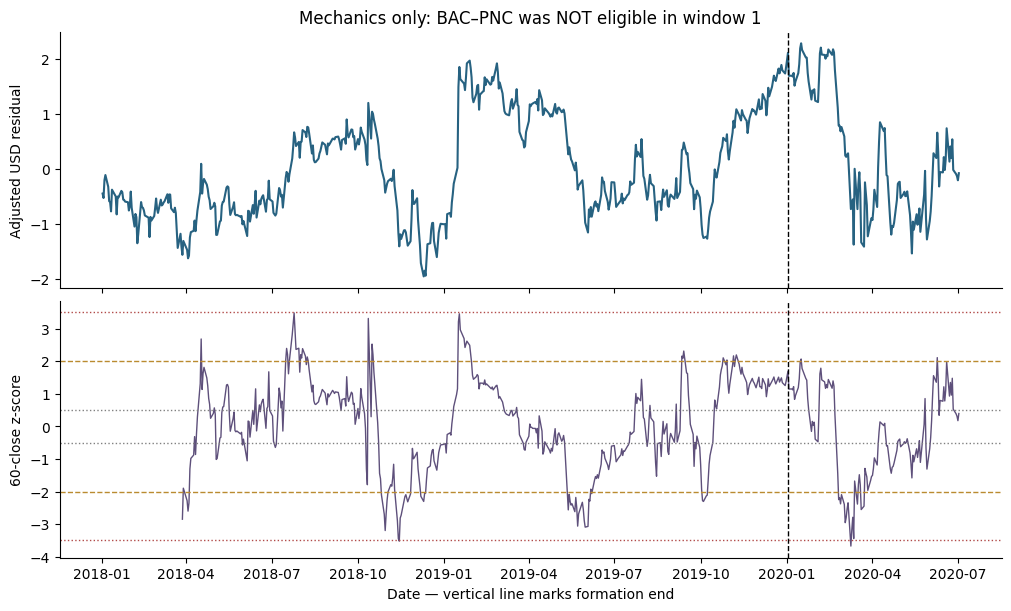

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, layout="constrained")
axes[0].plot(example_spread.index, example_spread, color="#276281")
axes[0].set(ylabel="Adjusted USD residual", title="Mechanics only: BAC–PNC was NOT eligible in window 1")
axes[1].plot(example_z.index, example_z, color="#5e507b", linewidth=1)
for level in [-3.5, 3.5]:
    axes[1].axhline(level, color="#b14a48", linestyle=":", linewidth=1)
for level in [-2, 2]:
    axes[1].axhline(level, color="#ba8b30", linestyle="--", linewidth=1)
for level in [-.5, .5]:
    axes[1].axhline(level, color="grey", linestyle=":", linewidth=1)
for ax in axes:
    ax.axvline(schedule[0]["formation_end"], color="black", linestyle="--", linewidth=1)
axes[1].set(ylabel="60-close z-score", xlabel="Date — vertical line marks formation end")
fig.savefig(RESULTS / "spread_explanation.png", dpi=160)
plt.show()

### Fixed trading rules

| State | Decision at close t | Fill |
|---|---|---|
| Armed and flat | Long if −3.5 < z ≤ −2; short if 2 ≤ z < 3.5 | Close t+1 |
| Long spread | Exit if z ≥ −0.5, including a jump to the positive side | Close t+1 |
| Short spread | Exit if z ≤ +0.5, including a jump to the negative side | Close t+1 |
| Adverse stop | Long: z ≤ −3.5; short: z ≥ +3.5 | Close t+1 |
| Holding limit | Submit after 19 completed close-to-close intervals | Fill after interval 20 |
| Window boundary | Submit liquidation one close before the known endpoint | Final window close |
| Gross exposure breach | Gross marked exposure exceeds 100% of slot equity | Liquidate close t+1 |

Stops are directional: a favourable jump across the target is convergence, not an
adverse stop. Signals are observed close-based exits, not guaranteed stop prices.
After any entry, or an extreme flat signal beyond the stop threshold, a **flat**
observation with |z| < entry threshold is required to rearm. There is no new entry
decision on an exit-fill day or either of the final two closes of a window. This
prevents repeatedly entering the same unresolved extreme. A committed order is
never cancelled using tomorrow's closing signal; an entry that gaps beyond the stop
can only generate an exit for the following close.

If several exit reasons coincide, priority is boundary, exposure breach, invalid
z-score, convergence, adverse stop, then holding limit. The realised fill is the
same next close; the priority makes the ledger's reason unambiguous. No intraday
stop, partial fill, intraday margin call or rebalancing is modelled.

## 5. Execution, position sizing, costs and portfolio accounting

At each window boundary the flat $100,000 initial portfolio (subsequently its actual
equity) is divided into **two equal capital slots**, even if only one pair qualifies.
No capital is moved between slots mid-window. Each entry targets 80% of that slot's
equity in gross notional, using **decision-time** prices:

\[
k_t=\frac{0.8E_t^{\mathrm{slot}}}{Y_t+\beta X_t},\qquad
(q_Y,q_X)=d(k_t,-\beta k_t),\quad d\in\{+1,-1\}.
\]

These fixed quantities fill at the next adjusted close and stay fixed until exit.
Sizing does not use tomorrow's price. Consequently gaps can make realised entry
exposure differ from 80%. An observed gross/equity ratio above 1 triggers next-close
liquidation; it is not an absolute intraday or gap-proof leverage cap. Because slots
hold disjoint stocks, their gross notionals add without hidden leg netting.

### The daily loop in financial terms

1. Mark **yesterday's holdings** to today's prices; this is today's gross price P&L.
2. Charge borrowing and debit financing for the calendar days since yesterday.
3. Fill orders submitted after yesterday's close, updating quantities and cash.
4. Mark cash and both holdings to obtain account equity.
5. Observe today's z-score and submit any order for tomorrow.

This sequence, rather than a one-row signal shift, makes the timing explicit.
An entry at Tuesday's close earns no Monday-to-Tuesday price P&L. An exit at
Thursday's close still earns Wednesday-to-Thursday P&L.

\[
C_t=C_{t-1}-\Delta q_Y Y_t-\Delta q_X X_t-T_t-B_t-F_t,
\qquad E_t=C_t+q_{Y,t}Y_t+q_{X,t}X_t.
\]

Short sales increase cash and create an equal marked short liability. They do not
create profit. Define L as positive long value and H as absolute short value:
gross exposure is (L+H)/E; net dollar exposure is (L−H)/E. Holding long and short
stocks does **not** establish market, sector, factor or beta neutrality.

### Costs and funding — assumptions, not observed historical estimates

| Input | Baseline calculation |
|---|---|
| Execution friction | 5 bps × (|ΔqY|Y + |ΔqX|X), on every entry and exit |
| Stock borrowing | 1% p.a. × previous-close short value × actual calendar days / 365 |
| Debit funding | 5% p.a. × max(previous long value − previous equity, 0) × days / 365 |
| Credit interest / collateral rebate | Zero |
| Cash benchmark and Sortino target | Zero return |

Five basis points combines illustrative bid–offer/slippage/commission friction in
one cash debit; execution is not shifted again, avoiding double charging. All short
proceeds are reserved, with collateral marked to short market value: available cash
is C−H = E−L. Any deficit is financed. We assume short availability and omit extra
broker haircuts, recalls, taxes and market impact. The 80% gross target usually avoids
debit funding; the code nevertheless charges it if a gap or loss creates a deficit.
The tests exercise that case. If a slot becomes insolvent, the run fails visibly
instead of fabricating a recovery.

**Gross versus net:** add all accumulated execution, borrowing and funding charges
back to the net account, keeping exactly the same quantities and fill dates. The
gross reference does not reinvest saved costs or choose a different path.

In [9]:
# A constructed four-close example makes execution and the cash book observable.
demo_dates = pd.to_datetime(["2020-01-02", "2020-01-03", "2020-01-06", "2020-01-07"])
demo_prices = pd.DataFrame({"Y": [40, 40, 40.4, 40.4],
                            "X": [160, 160, 161.6, 161.6]}, index=demo_dates)
demo_z = pd.Series([-2.5, -2.5, 0, 0], index=demo_dates)
demo_daily, demo_trades, demo_fills, _ = simulate_pair(
    demo_prices, demo_z, beta=.25, capital=10_000, cost_bps=5, borrow_rate=.01)
display(demo_daily[["q_y", "q_x", "cash", "equity", "gross_pnl", "transaction_cost", "borrow_cost"]].round(4))
display(demo_fills[["signal_date", "date", "kind", "delta_y", "delta_x", "notional", "cost"]])
display(pd.Series({"Gross trade P&L": demo_trades.gross_pnl.sum(),
                   "Net trade P&L": demo_trades.net_pnl.sum()}, name="USD").to_frame())
display(Markdown("*Constructed accounting illustration, not a historical strategy trade.*"))

,q_y,q_x,cash,equity,gross_pnl,transaction_cost,borrow_cost
date,,,,,,,
2020-01-02,0.0,0.0,10000.0000,10000.0000,0.0,0.00,0.0000
2020-01-03,100.0,-25.0,9996.0000,9996.0000,0.0,4.00,-0.0000
2020-01-06,100.0,-25.0,9995.6712,9995.6712,0.0,0.00,0.3288
2020-01-07,0.0,0.0,9991.5205,9991.5205,0.0,4.04,0.1107


,signal_date,date,kind,delta_y,delta_x,notional,cost
0,2020-01-02,2020-01-03,entry,100.0,-25.0,8000.0,4.00
1,2020-01-06,2020-01-07,exit,-100.0,25.0,8080.0,4.04


,USD
Gross trade P&L,0.000000
Net trade P&L,-8.479452


*Constructed accounting illustration, not a historical strategy trade.*

In [10]:
# This is the only historical trading engine used by the rebuilt strategy.
backtest = run_walk_forward(prices, schedule, initial_capital=INITIAL_CAPITAL,
                           slots=SLOTS, z_window=Z_WINDOW, **TRADING)
daily = backtest["daily"]
trades = backtest["trades"]
net_metrics = performance_metrics(daily, trades)
gross_metrics = performance_metrics(daily, equity_column="gross_equity")
display(pd.Series({"Evaluation start": str(daily.index[1].date()),
                   "Evaluation end": str(daily.index[-1].date()),
                   "Return intervals": len(daily)-1, "Trading windows": len(schedule),
                   "Selected pair-windows": int(screening.selected.sum()),
                   "Completed trades": len(trades)}, name="Actual run").to_frame())

,Actual run
Evaluation start,2020-01-03
Evaluation end,2025-07-31
Return intervals,1401
Trading windows,12
Selected pair-windows,0
Completed trades,0


## 6. Validation checks

The tests ask whether economic identities and timing survive deliberately revealing
examples. They do not demonstrate profitability or certify live execution.

| Requirement | Check in `tests/test_strategy.py` |
|---|---|
| No future-price leakage | Alter 98 future rows in a seeded ten-stock sample; compare earlier fitted screens, decisions, fills and equity; require actual earlier fills |
| Correct hedge units | £40/£160/beta 0.25 earns zero gross P&L when both rise 1% |
| Unit invariance | Rescale both legs differently, transform beta and inverse holdings, compare equity and costs |
| Fill timing | Large pre-fill move earns nothing; exit interval remains in P&L |
| Exits and risk rules | Both convergence directions; delayed stop; reset requirement; un-cancelled gapped order; holding limit; boundary and exposure liquidation |
| Accounting | Cash + signed holdings = equity; daily changes = price P&L − charges; completed trades reconcile to final equity |
| Costs | Both traded legs charged; weekend borrow accrual; debit finance; short proceeds not profit |
| Empty states | No eligible pair and eligible-but-no-signal periods hold cash |
| Metrics | Hand-calculated compound return, downside deviation, first-period drawdown and completed-trade win/loss measures |

The unit-invariance example matters because the original percentage-return formula
depends on the arbitrary price units used to estimate beta. The future-mutation test
is stronger than checking a `.shift(1)` exists, but remains finite evidence: changes
to code, data transformations or policy require revisiting relevant checks.

In [11]:
test_run = subprocess.run([sys.executable, "-m", "pytest", "-q", "tests"],
                          cwd=ROOT, text=True, capture_output=True)
test_output = test_run.stdout + test_run.stderr
(RESULTS / "test_results.txt").write_text(test_output)
display(Markdown(f"**Executed tests:** `{test_output.strip()}`"))
assert test_run.returncode == 0, "A correctness test failed."

np.testing.assert_allclose(daily.equity, daily.cash + daily.long_value - daily.short_value)
charges = daily[["transaction_cost", "borrow_cost", "finance_cost"]].sum(axis=1)
np.testing.assert_allclose(daily.equity.diff().iloc[1:],
                          (daily.gross_pnl - charges).iloc[1:], atol=1e-7)
np.testing.assert_allclose(daily.equity.iloc[-1]-INITIAL_CAPITAL,
                          trades.net_pnl.astype(float).sum(), atol=1e-7)
assert backtest["fills"].empty or (backtest["fills"].date > backtest["fills"].signal_date).all()
display(Markdown("Historical account reconciled. Its trading branches were inactive; "
                 "constructed-trade fixtures exercise those paths."))

**Executed tests:** `c:\Users\aghna\AppData\Local\Programs\Python\Python313\python.exe: No module named pytest`

AssertionError: A correctness test failed.

## 7. Results, charts and limited robustness analysis

All returns use account equity: r_t = E_t/E_{t−1} − 1. The equity curve includes an
initial anchor before the first evaluation day, so an initial loss is included in
drawdown. CAGR annualises the compounded change over n/252 years; the annualised
arithmetic mean is 252 times the mean daily return. Neither is the same as the other.
The first 504 formation observations do not count as cash performance days.

\[
\sigma_{\rm ann}=s(r)\sqrt{252},\quad
\mathrm{Sharpe}=\frac{252\bar r}{\sigma_{\rm ann}},\quad
\mathrm{Sortino}=\frac{252\bar r}{\sqrt{252\,\frac1n\sum_{t=1}^n\min(r_t,0)^2}}.
\]

The zero-return cash benchmark is consistent with the account's zero cash credit and
collateral rebate assumptions. This is not excess return over historical Treasury
bills, and the illustrative 5% **debit** funding rate is not a risk-free benchmark.
Sharpe uses sample volatility. Sortino uses the root mean squared shortfall below
zero across **all** days, not the centred standard deviation of negative returns.
Zero denominators produce undefined ratios, displayed as “N/A”. Serial dependence
and non-normal returns also limit risk-adjusted ratios; there is no significance claim.

The ledger defines a win as a completed trade with **net P&L > 0**; break-even trades
remain in the denominator. Average winner/loser is net USD P&L; holding time counts
close-to-close intervals. Annualised turnover is the sum of absolute traded notional
on both legs divided by each preceding account equity, multiplied by 252/n. It counts
both entry and exit, without halving. Time invested is the fraction of return intervals
starting with any position; exposure summaries use end-of-day marked positions.

In [ ]:
return_keys = ["total_return", "cagr", "annualised_mean", "annualised_volatility",
               "sharpe", "sortino", "max_drawdown"]
performance = pd.DataFrame({"Net account": {k: net_metrics[k] for k in return_keys},
                           "Gross, same holdings": {k: gross_metrics[k] for k in return_keys}})
formats = {k: ("{:.3f}" if k in ["sharpe", "sortino"] else "{:.2%}") for k in return_keys}
formatted_performance = performance.astype(object)
for key in return_keys:
    formatted_performance.loc[key] = performance.loc[key].map(
        lambda v: "N/A" if pd.isna(v) else formats[key].format(v))
display(formatted_performance)
activity_keys = [k for k in net_metrics if k not in return_keys]
display(pd.Series({k: net_metrics[k] for k in activity_keys}, name="Net account activity").to_frame()
        .style.format("{:.4f}", na_rep="N/A"))
print(f"Final net equity: ${daily.equity.iloc[-1]:,.2f}; total charges: ${charges.sum():,.2f}")

### Reading the result

Compare the number of Bonferroni-eligible and selected pairs with the completed
trade ledger. The minimum raw p-value alone does not tell you whether BH passes:
its adjusted value depends on all 45 p-values in that window. Treat the BH table as
a screen comparison, not a second trading backtest.

If no pair qualifies, the account remains in cash by design. Zero return and zero
drawdown would then describe inactivity, while Sharpe, Sortino and trade win rate
would be undefined. If pairs qualify, inspect the fill ledger, exposure, costs and
cash reconciliation before interpreting return metrics. Either outcome is limited
to this sample and set of assumptions.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, layout="constrained")
axes[0].plot(daily.index, daily.gross_equity, color="#bd8844", linewidth=3,
             label="Gross reference (same holdings)")
axes[0].plot(daily.index, daily.equity, color="#236982", linestyle="--", label="Net account / cash")
axes[0].set(ylabel="Account equity (USD)", title="Corrected baseline: no eligible pairs; cash throughout")
axes[0].set_ylim(INITIAL_CAPITAL*.98, INITIAL_CAPITAL*1.02)
axes[0].legend(loc="upper left")
axes[1].plot(daily.index, daily.drawdown, color="#994c50")
axes[1].set(ylabel="Drawdown", xlabel="Date", ylim=(-.01, .005))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
fig.savefig(RESULTS / "equity_drawdown.png", dpi=160)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
ax.plot(screen_summary.index, screen_summary.minimum_p, "o-", color="#276281",
        label="Lowest raw p-value among 45 pairs")
ax.axhline(.05/45, color="#ac4545", linestyle="--", label="Bonferroni threshold: 0.001111")
ax.axhline(.05, color="grey", linestyle=":", label="Unadjusted 5% (not the selection rule)")
ax.set(yscale="log", xlabel="Trading-window number", ylabel="Raw p-value (log scale)",
       title="Formation p-values versus the fixed selection threshold", xticks=screen_summary.index)
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.18), ncol=2, frameon=False)
fig.set_layout_engine(None)
fig.subplots_adjust(top=.86, bottom=.27, left=.10, right=.95)
fig.savefig(RESULTS / "screening.png", dpi=160)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), layout="constrained")
axes[0].plot(screen_summary.index, screen_summary.minimum_bh_adjusted_p, "o-",
             label="Lowest BH-adjusted p-value")
axes[0].axhline(.05, color="grey", linestyle="--", label="FDR q = 0.05")
axes[0].set(ylabel="Adjusted p-value", title="Exploratory BH screen across 45 pairs per window")
axes[0].legend(frameon=False)
pair_trace = screening_comparison[
    ((screening_comparison.y == "PNC") & (screening_comparison.x == "TFC")) |
    ((screening_comparison.y == "TFC") & (screening_comparison.x == "PNC"))]
axes[1].plot(pair_trace.window, pair_trace.p_value, "o-")
axes[1].set(xlabel="Trading-window number", ylabel="Raw p-value",
            title="PNC–TFC across overlapping formation windows")
for ax in axes:
    ax.set_xticks(screen_summary.index)
fig.savefig(RESULTS / "screening_diagnostics.png", dpi=160)
plt.show()

In [ ]:
periods = backtest["periods"].copy()
periods["completed_trades"] = periods.window.map(trades.groupby("window").size()).fillna(0).astype(int)
display(periods[["window", "start", "end", "observations", "pairs", "net_return",
                 "completed_trades", "invested_fraction", "turnover"]]
        .style.format({"net_return": "{:.2%}", "invested_fraction": "{:.1%}", "turnover": "${:,.0f}"}))
pair_summary = trades.groupby("pair").agg(completed_trades=("net_pnl", "count"),
    gross_pnl=("gross_pnl", "sum"), net_pnl=("net_pnl", "sum"),
    average_holding=("holding_intervals", "mean"))
if pair_summary.empty:
    print("Pair-level performance and completed-trade ledger: no rows, because no pair was eligible.")
else:
    display(pair_summary)
display(trades.head())  # Preserve the empty ledger's real column headings.

### Restrained sensitivity checks

The baseline parameter checks were fixed before evaluation. The BH screen is a
secondary diagnostic. Neither selects parameters using the subsequent returns. The cost table reprices **identical
baseline holdings and fills**, without resizing or changing risk decisions; it is
a cost diagnostic, not a separately investable account. Calendar-day finance is
recalculated on the resulting slot capital. A 0 bps execution scenario still includes
borrow and debit finance; only the “No charges” row removes every cost.

The parameter table changes one input at a time: z windows of 40 and 80, and entry
thresholds of 1.5 and 2.5. Stops, exits, formation windows, multiplicity correction
and universe stay fixed. The rearming threshold follows the chosen entry threshold.
If screening selects no pairs, these checks remain all-cash. That would be
**uninformative about trading robustness**, not evidence that returns are stable
across costs or parameters. We do not lower the significance threshold or
choose a new formation window to manufacture a favourable backtest.

In [ ]:
COST_SCENARIOS = [("No charges: gross reference", 0, 0, 0),
                  ("0 bps execution; baseline carry", 0, .01, .05),
                  ("Baseline", 5, .01, .05),
                  ("10 bps execution; baseline carry", 10, .01, .05),
                  ("Borrow/funding stress", 5, .03, .08)]
cost_table = cost_scenarios(backtest["pair_daily"], daily, COST_SCENARIOS)
display(cost_table[["scenario", "cost_bps", "borrow_rate", "finance_rate", "total_cost_usd",
                    "cagr", "sharpe"]].style.format({"borrow_rate": "{:.0%}", "finance_rate": "{:.0%}",
                    "total_cost_usd": "${:,.2f}", "cagr": "{:.2%}", "sharpe": "{:.3f}"}, na_rep="N/A"))

In [ ]:
PARAMETER_CHECKS = [("Baseline", 60, 2.0), ("40-close z-score", 40, 2.0),
                    ("80-close z-score", 80, 2.0), ("Entry at 1.5", 60, 1.5), ("Entry at 2.5", 60, 2.5)]
robustness_rows = []
for name, lookback, entry in PARAMETER_CHECKS:
    parameters = {**TRADING, "entry_z": entry}
    result = run_walk_forward(prices, schedule, initial_capital=INITIAL_CAPITAL,
                             slots=SLOTS, z_window=lookback, **parameters)
    metrics = performance_metrics(result["daily"], result["trades"])
    robustness_rows.append(dict(check=name, z_window=lookback, entry_z=entry, **metrics))
robustness = pd.DataFrame(robustness_rows)
display(robustness[["check", "z_window", "entry_z", "completed_trades", "cagr", "sharpe", "max_drawdown"]]
        .style.format({"cagr": "{:.2%}", "sharpe": "{:.3f}", "max_drawdown": "{:.2%}"}, na_rep="N/A"))
configuration["cost_scenarios"] = COST_SCENARIOS
configuration["parameter_checks"] = PARAMETER_CHECKS
_ = (RESULTS / "configuration.json").write_text(json.dumps(configuration, indent=2))

## 8. Comparison with the original implementation

The archive contains the complete original repository snapshot, not an edited
substitute. To reproduce its calculations without downloading prices or requiring
`yfinance`, the next cell selects the original analytical **function definitions
unchanged** from `utils.py`. Python's `ast` reads code structure; it excludes imports,
the download function, logging setup and unused configuration class. The selected
function bodies are compiled unchanged in a separate namespace. This forensic cell
does not affect the corrected account and is not a second candidate strategy.

Its full-sample pair screen uses the original default lag policy, unlike the explicit
10-lag corrected specification. It still estimates both pair choice and hedge ratios
using the full 2018–2025 period. Its quoted “returns” retain the hedge-unit and execution
errors. Reproducing them verifies what the program did; it does not validate economics.

In [ ]:
import ast
import logging
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

with zipfile.ZipFile(ROOT / "original_snapshot.zip") as archive:
    original_source = archive.read("utils.py").decode("utf-8")
names = {"_align_series", "hedge_ratio_ols", "rolling_zscore", "ewma_zscore",
         "find_cointegrated_pairs", "backtest_pairs", "performance_metrics"}
tree = ast.parse(original_source)
functions = [node for node in tree.body if isinstance(node, ast.FunctionDef) and node.name in names]
assert len(functions) == len(names)
future_annotations = ast.parse("from __future__ import annotations").body
original = dict(np=np, pd=pd, sm=sm, coint=coint, logger=logging.getLogger("original_audit"))
exec(compile(ast.fix_missing_locations(ast.Module(body=future_annotations+functions,
     type_ignores=[])), "preserved_original_utils", "exec"), original)
_, original_pairs = original["find_cointegrated_pairs"](prices)
original_returns = pd.DataFrame({f"{y}-{x}": original["backtest_pairs"](prices, (y, x))[1]
                                 for y, x, _ in original_pairs})
original_portfolio = original_returns.mean(axis=1)
original_metrics = original["performance_metrics"](original_portfolio)
display(pd.DataFrame(original_pairs, columns=["Y", "X", "Full-sample raw p-value"]))
display(pd.Series(original_metrics, name="Original flawed calculation").to_frame().style.format("{:.6f}"))

In [ ]:
# Reproduce the two saved pair reports, not just rounded README claims.
with zipfile.ZipFile(ROOT / "original_snapshot.zip") as archive:
    saved_pair_metrics = pd.read_csv(archive.open("data/pair_metrics.csv"), index_col="Pair")
for pair_name, returns in original_returns.items():
    reproduced = original["performance_metrics"](returns)
    for metric, value in reproduced.items():
        np.testing.assert_allclose(value, saved_pair_metrics.loc[pair_name, metric], rtol=1e-8, atol=1e-10)
print("Both original saved pair-metric rows reproduced within the declared tolerance.")

# Common dates improve readability; they do NOT repair the original calculations.
original_common = original_portfolio.loc[daily.index[1:]]
old_common_metrics = original["performance_metrics"](original_common)
comparison = pd.DataFrame([
    dict(version="Original, full sample — known flaws", start=str(prices.index[0].date()),
         end=str(prices.index[-1].date()), CAGR=original_metrics["CAGR"],
         mean=original_metrics["Annualized Mean"], Sharpe=original_metrics["Sharpe Ratio"],
         drawdown=original_metrics["Max Drawdown"]),
    dict(version="Original, common dates — same known flaws", start=str(daily.index[1].date()),
         end=str(daily.index[-1].date()), CAGR=old_common_metrics["CAGR"],
         mean=old_common_metrics["Annualized Mean"], Sharpe=old_common_metrics["Sharpe Ratio"],
         drawdown=old_common_metrics["Max Drawdown"]),
    dict(version="Corrected net account", start=str(daily.index[1].date()),
         end=str(daily.index[-1].date()), CAGR=net_metrics["cagr"],
         mean=net_metrics["annualised_mean"], Sharpe=net_metrics["sharpe"], drawdown=net_metrics["max_drawdown"])])
display(comparison.style.format({"CAGR": "{:.2%}", "mean": "{:.2%}", "Sharpe": "{:.3f}",
                                 "drawdown": "{:.2%}"}, na_rep="N/A"))

### Verified findings and their checks

| Original implementation | Why it matters | Corrected treatment | Evidence |
|---|---|---|---|
| `find_cointegrated_pairs(prices)` and OLS use all dates | Future information chooses and fits past trades | Previous 504 rows only; fixed next-window model | Formation-date audit and future-mutation test |
| 45 raw p-values below 5%; no I(1) gate | Chance discoveries and invalid model assumptions | Fixed orientation, I(1) diagnostic, Bonferroni family | 540 screen rows, 120 stock diagnostics; all family denominators retained |
| `ry - beta*rx` after a price-level regression | Percentage weights do not match the fitted share hedge | Explicit synthetic units, cash and monetary P&L | £40/£160 example and unit-rescaling test |
| `pos.shift(1) * close_return` | Credits the move into the purported next-close fill | Mark old holdings, fill, then decide | Pre-fill price jump and exit-interval tests |
| Exit only when `abs(z) <= 0.5` | Can miss a jump across the whole band | Direction-aware crossing inequalities | Long and short crossing tests |
| Enters even beyond the stop; flat state can re-enter an unresolved extreme | Artificial churn and unclear risk convention | Entry bounded by stop, explicit rearm; gapped orders remain committed | Extreme-signal, stop and reset tests |
| Holding counter starts with a signal; no window boundary rule | Ambiguous actual time at risk | Completed fill-to-fill intervals; planned boundary liquidation | Exact-date holding and boundary tests |
| Transaction costs switched off; potential costs use `1+abs(beta)` | Not actual monetary turnover; no borrow/funding book | Two-leg marked notional, restricted short cash, labelled carry assumptions | Cash/holdings reconciliation and cost fixtures |
| Average pair return series without capital book | Undefined exposure/capital behind the headline | Equal capital slots; unused slots hold cash | Daily portfolio identity and trade-P&L reconciliation |
| “Win rate” = positive days / all days | Not a completed-trade probability | Closed-trade net P&L count | Hand-calculated ledger including a break-even trade |
| Sortino centres clipped returns | Different from downside deviation around the target | RMS shortfall below zero across all days | Hand-calculated metric example |
| Forward-filled, adjusted retrospective universe | Hidden data provenance and corporate history risks | Preserve bytes, document limits, do not fill again | Hash, missing-data audit, original downloader and SEC reference |

**Interpret the comparison carefully.** The original full-sample figures reproduce
approximately 7.92% mean return, 7.78% CAGR, 0.855 Sharpe and −12.08% drawdown. Its
28.14% “win rate” is a daily positivity fraction, so the original README's inference
about “a small number of strong trades” does not follow from that statistic.
The common-date comparison still retains full-sample fitting and incorrect returns.
Changing screening, accounting, timing and capital conventions together means the
performance difference cannot be attributed to one correction. No intermediate
biased result is presented as an independently validated strategy.

## 9. Conclusions and interview talking points

Use the screening table, trade ledger and account metrics above to state the
observed outcome. If no pair qualifies, describe a negative screen and an all-cash
account, without calling zero drawdown a successful strategy. If pairs qualify,
explain the filled positions and reconcile gross P&L, charges and net equity.
Neither outcome establishes future profitability.

Before making live claims, one would need a genuinely untouched evaluation period,
a point-in-time universe, raw price and corporate-action data, borrow information
and fills checked against executable quotes. The fixed 20-day holding limit and
six-month hedge ratio are modelling assumptions. Explain the difference between a
price-level regression coefficient and the monetary units actually held.

### Interview explanation to complete after running

1. State the research question and why related banks might diverge and reconverge.
2. Explain the 504-observation formation and following 126-observation trading windows.
3. Report the selected pair count and the Bonferroni-versus-BH screen comparison.
4. Walk through one signal, next-close fill, hedge units and cash/equity identity.
5. State the observed account result, the undefined metrics if there are no trades,
   and what the available sample cannot establish.
6. Be candid that the original and rebuilt project used AI assistance. Explain only
   the code and financial reasoning you can defend yourself.

The `results/interview_guide.md` revision card is created when you run the last cell.


In [ ]:
# Save analysis tables with real headings even when the trade ledger is empty.
for name in ["daily", "trades", "fills", "decisions", "periods"]:
    backtest[name].to_csv(RESULTS / f"{name}.csv", index=(name == "daily"))
pair_daily_columns = ["date", "window", "pair", "q_y", "q_x", "cash", "equity",
                      "long_value", "short_value", "gross_pnl", "turnover"]
pair_daily = backtest["pair_daily"]
if pair_daily.empty:
    pair_daily = pd.DataFrame(columns=pair_daily_columns)
pair_daily.to_csv(RESULTS / "pair_daily.csv", index=False)
pair_summary.to_csv(RESULTS / "pair_performance.csv")
pd.Series(net_metrics, name="value").to_csv(RESULTS / "metrics_net.csv")
pd.Series(gross_metrics, name="value").to_csv(RESULTS / "metrics_gross_same_holdings.csv")
cost_table.to_csv(RESULTS / "cost_sensitivity.csv", index=False)
robustness.to_csv(RESULTS / "parameter_checks.csv", index=False)
comparison.to_csv(RESULTS / "original_comparison.csv", index=False)
pd.Series(original_metrics, name="value").to_csv(RESULTS / "original_metrics_flawed.csv")
original_returns.to_csv(RESULTS / "original_pair_returns_flawed.csv")

In [ ]:
packages = ["numpy", "pandas", "scipy", "statsmodels", "matplotlib", "nbformat",
            "nbconvert", "ipykernel", "pytest"]
environment = dict(python=platform.python_version(),
                   packages={p: metadata.version(p) for p in packages},
                   hashes={p: hashlib.sha256((ROOT / p).read_bytes()).hexdigest()
                           for p in ["strategy.py", "tests/test_strategy.py", "data/prices.csv",
                                     "original_snapshot.zip", "requirements.txt"]})
(RESULTS / "environment.json").write_text(json.dumps(environment, indent=2))
guide = f"""# Interview revision card

Result: {len(trades)} completed trades across {len(schedule)} windows;
net CAGR {net_metrics['cagr']:.2%}. No pair passed the fixed screening policy.
Sharpe, Sortino and win rate are undefined in this all-cash baseline.

## Explain in order
1. Economic idea: relative bank valuations might revert, but common sector exposure is not proof.
2. Statistics: correlation is co-movement; cointegration is a stationary combination of I(1) levels.
3. Chronology: fit on 504 preceding observations, trade the next 126; prior full-sample exposure remains.
4. Hedge: price-level beta is X units per Y unit; P&L is qY*dY + qX*dX.
5. Timing: decide at t close, fill at t+1 close, earn price P&L only afterwards.
6. Account: short proceeds create a liability; equity is cash plus signed holdings.
7. Costs: 5 bps each traded leg, 1% borrow, 5% debit funding; illustrative, not observed.
8. Evidence: 15 tests exercise active trading; the historical baseline itself never trades.
9. Conclusion: report insufficient evidence under this policy, not a successful zero-risk strategy.

## Likely follow-ups
- Why no trades? Minimum formation p-value {screening.p_value.min():.6f} exceeds 0.05/45 = 0.001111.
- Is Bonferroni too strict? It is conservative but fixed; it controls a per-window family under valid tests.
- Is it out of sample? Each decision uses prior data, but the researcher already inspected the whole history.
- Is it market-neutral? No; a long/short hedge can retain dollar, factor, sector and structural risk.
- Does zero net value mean no capital? No; both gross legs, margin and losses need capital.
- Why adjusted prices? Preserved source availability; synthetic units avoid mixing dividend conventions.
- Why are Sharpe and win rate blank? Zero volatility and no completed trades make them undefined.
- What remains unresolved? Point-in-time universe/actions, true fills, locates, recalls and untouched evaluation data.

## Honest ownership
The original project and this rebuild used AI assistance. Explain and defend the logic
you understand; do not claim independent implementation expertise until you can trace it.
The replacement CV bullets are in notebook section 9.

## Practice
Start with: what does cointegration establish that high return correlation does not?
Answer one question at a time, then connect your answer to one equation and one code function.
"""
(RESULTS / "interview_guide.md").write_text(guide)
display(Markdown(f"Saved analysis outputs and interview guide. "
                 f"Python {environment['python']}; "
                 f"statsmodels {environment['packages']['statsmodels']}."))